# M04 - Coronary Territory Scar Analysis

Groups AHA 17-segment polar-map scar burden by coronary territory (Cerqueira et al. 2002)
and tests clinical associations.

| Section | Contents |
|---|---|
| 1 | Setup, data loading, clinical labels |
| 2 | Polar map computation and example plots |
| 3 | AHA segment grid and territory map |
| 4 | Per-patient territory scar burden |
| 5 | Population-level distributions |
| 6 | Age correlations (territory scar + core zone clinical metrics) |
| 7 | Sex differences (t-test + ANOVA) |

**Territory assignment (Cerqueira et al. 2002, right-dominant ~85%):**
- **LAD**: segments 1, 2, 7, 8, 13, 14, 17 — anterior + anteroseptal + apex
- **RCA**: segments 3, 4, 9, 10, 15 — inferoseptal + inferior
- **LCX**: segments 5, 6, 11, 12, 16 — inferolateral + anterolateral

> **Limitation**: analysis uses the standard AHA territory model as a proxy.
> Angiographic confirmation of culprit artery is not available in this dataset.
> Individual coronary anatomy (dominance, overlap) introduces variability.

## Section 1 - Setup, Data Loading, and Clinical Labels

### 1.1 Imports and Configuration

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, spearmanr, pearsonr, f_oneway, friedmanchisquare, levene
from tqdm import tqdm


def find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (base, base / 'lv-scar-segmentation'):
            if (candidate / 'src' / 'data_loading.py').exists():
                return candidate.resolve()
    raise FileNotFoundError('Could not locate lv-scar-segmentation.')


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for mod in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[mod]

from src.data_loading import scan
from src.mesh_utils import best_shell, get_cz_mesh, best_rv_mesh
from src.lv_geometry import (
    long_axis,
    rv_reference_pca,
    rv_reference_from_rv_mesh,
    prepare_polar_geometry,
    project_points_to_polar,
    polar_mask,
)

HD_ROOT      = r'F:/RM_TEKNON_DEVELOP'
CLINICAL_CSV = Path(r'C:/Users/joan/Desktop/FEINA/UPF/TFG/develop-vt.csv')
RESULTS      = ROOT / 'results'
SPLIT_JSON   = RESULTS / 'split.json'
OUT          = RESULTS / 'M04_scar_analysis'
OUT.mkdir(parents=True, exist_ok=True)

N_R     = 64
N_THETA = 128

AHA_DISPLAY_DEG = 0.0    # no roll: septal/RV vector stays at West (9 o'clock)

# Threshold: fraction of territory bins occupied to call a territory 'involved'
SCAR_THRESH = 0.05

TERR_COLORS = {'LAD': '#d62728', 'RCA': '#1f77b4', 'LCX': '#2ca02c'}

plt.rcParams['figure.dpi'] = 120
print(f'Project root: {ROOT}')
print('Config done.')

Project root: C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation
Config done.


### 1.2 Data Loading

In [2]:
all_cases = scan(HD_ROOT)

with open(SPLIT_JSON) as f:
    split = json.load(f)
known_keys = set(split['known'])

case_by_key = {f'{c.year}/{c.patient_id}': c for c in all_cases}
known = [
    case_by_key[k] for k in known_keys
    if k in case_by_key
    and case_by_key[k].tissue_surfaces.get('core') is not None
    and best_shell(case_by_key[k]) is not None
]

print(f'Known cases with shell + core zone: {len(known)}')
n_bz = sum(1 for c in known if c.tissue_surfaces.get('border_zone') is not None)
print(f'  of which have border zone mesh  : {n_bz} ({100*n_bz/max(len(known),1):.0f}%)')

Known cases with shell + core zone: 84
  of which have border zone mesh  : 84 (100%)


### 1.3 Clinical Labels (Sex and Age)

In [3]:
sex_map  = {}   # patient_id -> 'M' or 'F'
age_map  = {}   # patient_id -> float
core_pct_map   = {}  # patient_id -> float (core zone % of LV mass)
bz_core_pct_map = {} # patient_id -> float (core+BZ % of LV mass)
core_g_map = {}      # patient_id -> float (core zone grams)

if CLINICAL_CSV is not None and CLINICAL_CSV.exists():
    try:
        from src.clinical_data import load as _load_clinical
        _clin = _load_clinical(CLINICAL_CSV)

        for col, d in [('sex', sex_map), ('age', age_map),
                        ('core_pct', core_pct_map),
                        ('bz_core_pct', bz_core_pct_map),
                        ('core_g', core_g_map)]:
            if col in _clin.columns and 'patient_id' in _clin.columns:
                for _, row in _clin[['patient_id', col]].dropna().iterrows():
                    pid = str(row['patient_id']).strip().rstrip('.0')
                    d[pid] = row[col]

        # Recode sex to M/F
        sex_map = {pid: ('M' if int(v) == 1 else 'F')
                   for pid, v in sex_map.items() if int(v) in (1, 2)}

        print(f'Sex    : {len(sex_map)}  M={sum(v=="M" for v in sex_map.values())}  '
              f'F={sum(v=="F" for v in sex_map.values())}')
        print(f'Age    : {len(age_map)}')
        print(f'core_pct    : {len(core_pct_map)}')
        print(f'bz_core_pct : {len(bz_core_pct_map)}')
    except Exception as exc:
        print(f'Clinical loading failed: {exc}')
else:
    print(f'Clinical CSV not found: {CLINICAL_CSV}')

Sex    : 94  M=79  F=15
Age    : 94
core_pct    : 165
bz_core_pct : 165


## Section 2 - Polar Map Computation

### How polar maps are built

Each patient produces one 64x128 binary polar map from their 3-D meshes:

1. **Meshes loaded**: LV shell (myocardium surface) and **core zone** scar mesh
   (`tissue_surfaces['core']`). The core zone is the densely fibrotic region
   identified by the ADAS3D segmentation; it excludes the peri-infarct border zone.

2. **Long axis**: PCA of LV shell vertices gives the apex-to-base axis.
   The apex is identified as the pointed tip.

3. **Circumferential reference (theta = 0)**: set at the RV insertion point
   (septum). Preferred source is the RV mesh centroid relative to the LV
   centroid in the basal cross-section (Method C). Falls back to PCA of the
   concave side of the basal ring (Method B) when no RV mesh is available.

4. **Projection**: each CZ vertex is mapped to
   - `s` = fractional position along long axis (0 = apex, 1 = base)
   - `theta` = circumferential angle from septal reference, increasing
     **clockwise**: 0 = septum -> 90 deg = anterior -> 180 deg = lateral ->
     270 deg = inferior.

5. **Binning**: (s, theta) mapped to a 64 x 128 integer grid.
   Each bin = **1 if any CZ vertex falls there, 0 otherwise**.

6. **Bullseye orientation** (set_theta_zero_location='W', direction=-1):
   centre = apex, outermost ring = base, septum at 9 o'clock (West).

In [4]:
import pyvista as pv


def _get_bz_mesh(case):
    """Load border zone mesh (returns None if not available)."""
    path = case.tissue_surfaces.get('border_zone')
    if path is None or not path.exists():
        return None
    return pv.read(str(path))


def _build_polar_map(lv_shell, scar_mesh, rv_mesh=None, n_r=N_R, n_theta=N_THETA):
    """
    Project scar_mesh vertices onto the LV polar grid.

    Returns (n_r, n_theta) bool array: True = scar vertex in that bin.
    Orientation: s=0 apex (centre), s=1 base (outer ring).
    theta=0 septum, increasing CW (ANT at top in bullseye display).
    """
    if rv_mesh is not None:
        ref_fn = lambda mesh, ax, ap: rv_reference_from_rv_mesh(mesh, rv_mesh, ax, ap)
        geom   = prepare_polar_geometry(lv_shell, ref_fn=ref_fn, rv_mesh=rv_mesh)
    else:
        geom = prepare_polar_geometry(lv_shell, rv_mesh=None)
    theta, s = project_points_to_polar(scar_mesh.points, geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)   # CW flip
    ri = np.clip((s * n_r).astype(int), 0, n_r - 1)
    ti = np.clip((theta / (2 * np.pi) * n_theta).astype(int), 0, n_theta - 1)
    return polar_mask(theta, s, n_r, n_theta, roll_deg=AHA_DISPLAY_DEG)
def _polar_map_for_case(case, use_rv=True):
    shell = best_shell(case)
    cz    = get_cz_mesh(case)
    if shell is None or cz is None:
        return None
    rv = best_rv_mesh(case) if use_rv else None
    return _build_polar_map(shell, cz, rv_mesh=rv)


def _polar_map_bz_for_case(case, use_rv=True):
    shell = best_shell(case)
    bz    = _get_bz_mesh(case)
    if shell is None or bz is None:
        return None
    rv = best_rv_mesh(case) if use_rv else None
    return _build_polar_map(shell, bz, rv_mesh=rv)


# Compute core zone polar maps (main analysis)
pmaps = {}
for case in tqdm(known, desc='Core zone polar maps'):
    key = f'{case.year}/{case.patient_id}'
    try:
        m = _polar_map_for_case(case, use_rv=True)
        if m is not None:
            pmaps[key] = m.astype(float)
    except Exception as e:
        print(f'  skip {key}: {e}')

# Compute border zone polar maps
pmaps_bz = {}
for case in tqdm(known, desc='Border zone polar maps'):
    key = f'{case.year}/{case.patient_id}'
    try:
        m = _polar_map_bz_for_case(case, use_rv=True)
        if m is not None:
            pmaps_bz[key] = m.astype(float)
    except Exception as e:
        pass   # BZ mesh often absent; silent skip

print(f'Core zone polar maps : {len(pmaps)}')
print(f'Border zone polar maps: {len(pmaps_bz)}')

Border zone polar maps: 100%|██████████| 84/84 [00:12<00:00,  6.49it/s]

Core zone polar maps : 84
Border zone polar maps: 84


### 2.1 Example Polar Maps

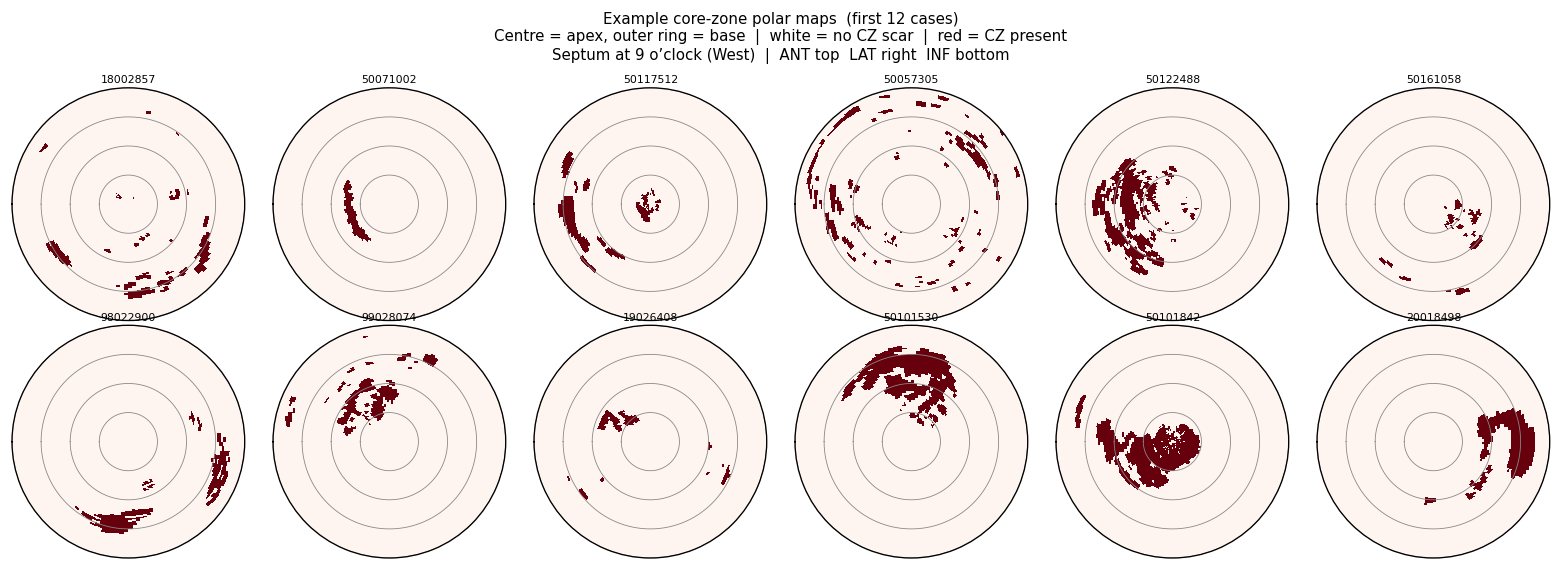

Saved example_polar_maps.png


In [5]:
# Show first N cases with available polar maps as bullseye plots
_SHOW_N  = 12
_NCOLS   = 6
_pm_keys = list(pmaps.keys())[:_SHOW_N]
_nrows   = int(np.ceil(len(_pm_keys) / _NCOLS))

fig = plt.figure(figsize=(_NCOLS * 2.2, _nrows * 2.4))
fig.suptitle(
    f'Example core-zone polar maps  (first {len(_pm_keys)} cases)\n'
    'Centre = apex, outer ring = base  |  white = no CZ scar  |  red = CZ present\n'
    'Septum at 9 o\u2019clock (West)  |  ANT top  LAT right  INF bottom',
    fontsize=9,
)

T_eg, R_eg = np.meshgrid(
    np.linspace(0, 2 * np.pi, N_THETA + 1),
    np.linspace(0, 1.0,       N_R + 1),
)

for idx, key in enumerate(_pm_keys):
    ax = fig.add_subplot(_nrows, _NCOLS, idx + 1, projection='polar')
    pm = pmaps[key]
    ax.pcolormesh(T_eg, R_eg, pm, cmap='Reds', vmin=0, vmax=1, shading='flat')
    # Ring boundaries
    t_f = np.linspace(0, 2 * np.pi, 361)
    for r_b in (0.25, 0.50, 0.75, 1.0):
        ax.plot(t_f, np.full_like(t_f, r_b), color='#888', lw=0.5)
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    ax.set_rticks([])
    ax.set_xticks([])
    pid = key.split('/')[-1]
    ax.set_title(pid, fontsize=6.5, pad=3)

plt.tight_layout()
plt.savefig(OUT / 'example_polar_maps.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved example_polar_maps.png')

## Section 3 - AHA Segment Grid and Coronary Territory Map

Each polar bin `(r, theta)` is assigned to one of the 17 AHA segments
(Cerqueira et al. 2002), then grouped into three coronary territories.

Convention: theta = 0 = septum (West), increasing clockwise.

| Territory | Segments | Wall |
|---|---|---|
| **LAD** | 1, 2, 7, 8, 13, 14, 17 | Anterior, anteroseptal, apical cap |
| **RCA** | 3, 4, 9, 10, 15 | Inferoseptal, inferior |
| **LCX** | 5, 6, 11, 12, 16 | Inferolateral, anterolateral |

In [6]:
def _aha_segment_grid(n_r=N_R, n_theta=N_THETA):
    labels = np.zeros((n_r, n_theta), dtype=np.int64)
    rc = (np.arange(n_r) + 0.5) / n_r
    tc = (np.arange(n_theta) + 0.5) / n_theta * 360.0
    for ri, radius in enumerate(rc):
        for ti, theta_deg in enumerate(tc):
            if radius < 0.25:
                labels[ri, ti] = 17
            elif radius < 0.50:
                if   45  <= theta_deg < 135: labels[ri, ti] = 13
                elif 135 <= theta_deg < 225: labels[ri, ti] = 16
                elif 225 <= theta_deg < 315: labels[ri, ti] = 15
                else:                        labels[ri, ti] = 14
            elif radius < 0.75:
                if   0   <= theta_deg < 60:  labels[ri, ti] = 8
                elif 60  <= theta_deg < 120: labels[ri, ti] = 7
                elif 120 <= theta_deg < 180: labels[ri, ti] = 12
                elif 180 <= theta_deg < 240: labels[ri, ti] = 11
                elif 240 <= theta_deg < 300: labels[ri, ti] = 10
                else:                        labels[ri, ti] = 9
            else:
                if   0   <= theta_deg < 60:  labels[ri, ti] = 2
                elif 60  <= theta_deg < 120: labels[ri, ti] = 1
                elif 120 <= theta_deg < 180: labels[ri, ti] = 6
                elif 180 <= theta_deg < 240: labels[ri, ti] = 5
                elif 240 <= theta_deg < 300: labels[ri, ti] = 4
                else:                        labels[ri, ti] = 3
    return labels


AHA_GRID = _aha_segment_grid()

SEG_LABELS = {
    1:'bas ant',  2:'bas ant-sep', 3:'bas inf-sep', 4:'bas inf',
    5:'bas inf-lat', 6:'bas ant-lat',
    7:'mid ant',  8:'mid ant-sep', 9:'mid inf-sep', 10:'mid inf',
    11:'mid inf-lat', 12:'mid ant-lat',
    13:'api ant', 14:'api sep',   15:'api inf',    16:'api lat', 17:'apex',
}

TERRITORY = {
    'LAD': [1, 2, 7, 8, 13, 14, 17],
    'RCA': [3, 4, 9, 10, 15],
    'LCX': [5, 6, 11, 12, 16],
}

SEG_TERRITORY = {s: t for t, segs in TERRITORY.items() for s in segs}

TERRITORY_GRID = np.full((N_R, N_THETA), '', dtype=object)
for terr, segs in TERRITORY.items():
    for seg in segs:
        TERRITORY_GRID[AHA_GRID == seg] = terr

# Number of polar bins per territory (denominator for scar burden)
TERR_NBINS = {t: int((TERRITORY_GRID == t).sum()) for t in TERRITORY}

print('Bins per territory (denominator):')
for t, n in TERR_NBINS.items():
    print(f'  {t}: {n} bins  ({100*n/(N_R*N_THETA):.1f}% of grid)')

Bins per territory (denominator):
  LAD: 4448 bins  (54.3% of grid)
  RCA: 1888 bins  (23.0% of grid)
  LCX: 1856 bins  (22.7% of grid)


## Section 4 - Per-Patient Territory Scar Burden

For each patient and territory:

- **Numerator**: number of polar bins in that territory occupied by at least
  one core-zone scar vertex.
- **Denominator**: total polar bins in that territory
  (fixed, depends only on the grid resolution and territory size).
- **Scar burden** = numerator / denominator (fraction of territory bins with scar).

In [7]:
rows = []
for key, pm in pmaps.items():
    pid = key.split('/')[-1]

    # Territory burden: CZ bins / total territory bins
    terr_burden = {}
    terr_cz_bins = {}
    for terr in TERRITORY:
        mask = (TERRITORY_GRID == terr)
        n_cz = int(pm[mask].sum())
        terr_cz_bins[terr] = n_cz
        terr_burden[terr]  = n_cz / TERR_NBINS[terr]

    dominant   = max(terr_burden, key=lambda t: terr_burden[t])
    n_involved = sum(1 for v in terr_burden.values() if v >= SCAR_THRESH)

    row = {
        'key':        key,
        'pid':        pid,
        'sex':        sex_map.get(pid, np.nan),
        'age':        float(age_map[pid])    if pid in age_map    else np.nan,
        'core_pct':   float(core_pct_map[pid]) if pid in core_pct_map else np.nan,
        'bz_core_pct': float(bz_core_pct_map[pid]) if pid in bz_core_pct_map else np.nan,
        'core_g':     float(core_g_map[pid]) if pid in core_g_map else np.nan,
        'LAD':        terr_burden['LAD'],
        'RCA':        terr_burden['RCA'],
        'LCX':        terr_burden['LCX'],
        'LAD_cz_bins': terr_cz_bins['LAD'],
        'RCA_cz_bins': terr_cz_bins['RCA'],
        'LCX_cz_bins': terr_cz_bins['LCX'],
        'dominant':   dominant,
        'n_involved': n_involved,
        'total_scar': float(pm.mean()),
    }
    rows.append(row)

df = pd.DataFrame(rows)

print(f'Patients: {len(df)}')
print(f'Sex known: {df["sex"].notna().sum()}  Age known: {df["age"].notna().sum()}')
print(f'core_pct known: {df["core_pct"].notna().sum()}')
print('\nTerritory burden  (mean +/- std)  [CZ bins / denom bins]:')
for terr in ('LAD', 'RCA', 'LCX'):
    mean_b = df[terr].mean()
    std_b  = df[terr].std()
    mean_cz = df[f'{terr}_cz_bins'].mean()
    denom   = TERR_NBINS[terr]
    print(f'  {terr}: {mean_b:.4f} +/- {std_b:.4f}  '
          f'(mean CZ bins: {mean_cz:.1f} / {denom})')
print(f'\nDominant territory:')
print(df['dominant'].value_counts().to_string())
print(f'\nTerritories involved (threshold={SCAR_THRESH:.2f}):')
print(df['n_involved'].value_counts().sort_index().to_string())

Patients: 84
Sex known: 32  Age known: 32
core_pct known: 63

Territory burden  (mean +/- std)  [CZ bins / denom bins]:
  LAD: 0.0534 +/- 0.0838  (mean CZ bins: 237.5 / 4448)
  RCA: 0.0466 +/- 0.0543  (mean CZ bins: 88.0 / 1888)
  LCX: 0.0507 +/- 0.0619  (mean CZ bins: 94.1 / 1856)

Dominant territory:
dominant
LCX    32
LAD    28
RCA    24

Territories involved (threshold=0.05):
n_involved
0    28
1    31
2    23
3     2


## Section 5 - Population-Level Territory Distributions

Each bar shows the mean per-patient scar burden for that territory.

**Bar metric** = mean across patients of (CZ-occupied bins / total territory bins).
The raw counts (numerator / denominator) are annotated on each bar.

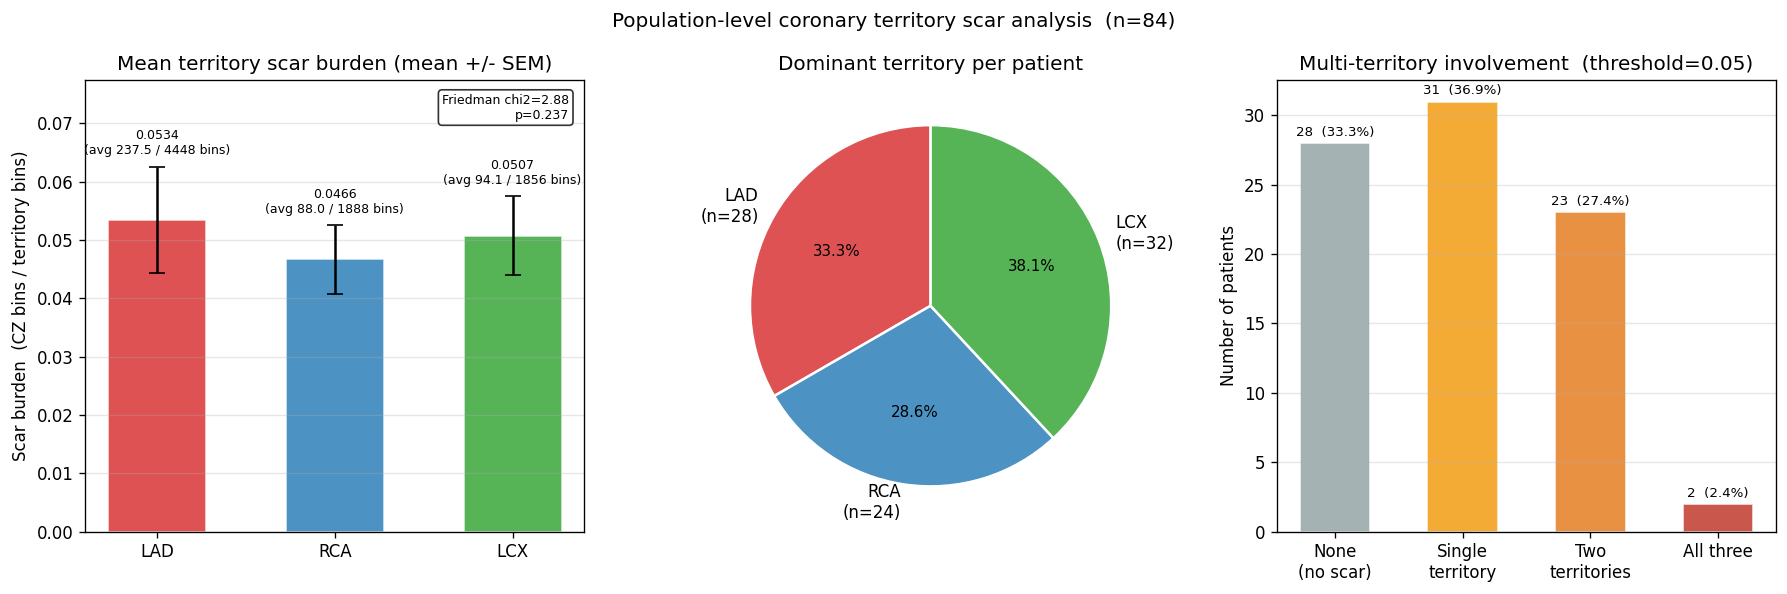

Saved territory_population.png


In [8]:
from scipy.stats import friedmanchisquare

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Population-level coronary territory scar analysis  (n={len(df)})',
             fontsize=12)

# --- Plot 1: Mean territory burden with numerator/denominator annotations ---
ax = axes[0]
terr_list   = ['LAD', 'RCA', 'LCX']
terr_means  = [df[t].mean()  for t in terr_list]
terr_sems   = [df[t].sem()   for t in terr_list]
terr_cols   = [TERR_COLORS[t] for t in terr_list]
bars = ax.bar(terr_list, terr_means, yerr=terr_sems, capsize=5,
              color=terr_cols, alpha=0.80, edgecolor='white', width=0.55)
for bar, t, mean, sem in zip(bars, terr_list, terr_means, terr_sems):
    mean_cz_bins = df[f'{t}_cz_bins'].mean()
    denom        = TERR_NBINS[t]
    ax.text(bar.get_x() + bar.get_width() / 2,
            mean + sem + max(terr_means) * 0.03,
            f'{mean:.4f}\n(avg {mean_cz_bins:.1f} / {denom} bins)',
            ha='center', va='bottom', fontsize=7.5)

# Friedman test: repeated measures within patients across territories
stat_fr, p_fr = friedmanchisquare(df['LAD'].values, df['RCA'].values, df['LCX'].values)
ax.text(0.97, 0.97,
        f'Friedman chi2={stat_fr:.2f}\np={p_fr:.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_ylabel('Scar burden  (CZ bins / territory bins)')
ax.set_title('Mean territory scar burden (mean +/- SEM)')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(terr_means) * 1.45)

# --- Plot 2: Dominant territory pie ---
ax = axes[1]
dom_counts = df['dominant'].value_counts()
dom_order  = [t for t in ('LAD', 'RCA', 'LCX') if t in dom_counts.index]
dom_vals   = [dom_counts.get(t, 0) for t in dom_order]
dom_cols   = [mcolors.to_rgba(TERR_COLORS[t], alpha=0.80) for t in dom_order]
wedges, texts, autotexts = ax.pie(
    dom_vals,
    labels=[f'{t}\n(n={v})' for t, v in zip(dom_order, dom_vals)],
    colors=dom_cols,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('Dominant territory per patient')

# --- Plot 3: Multi-territory involvement ---
ax = axes[2]
n_terr_counts = df['n_involved'].value_counts().sort_index()
labels_mt = {0: 'None\n(no scar)', 1: 'Single\nterritory',
             2: 'Two\nterritories', 3: 'All three'}
x_mt   = [labels_mt.get(int(k), str(k)) for k in n_terr_counts.index]
colors_mt = ['#95a5a6', '#f39c12', '#e67e22', '#c0392b']
bars_mt = ax.bar(x_mt, n_terr_counts.values,
                 color=colors_mt[:len(x_mt)], edgecolor='white', width=0.55, alpha=0.85)
for bar, val in zip(bars_mt, n_terr_counts.values):
    pct = 100 * val / len(df)
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val}  ({pct:.1f}%)', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Number of patients')
ax.set_title(f'Multi-territory involvement  (threshold={SCAR_THRESH:.2f})')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'territory_population.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved territory_population.png')

### 5.1 Population Mean Polar Map with Territory Overlay

Left: population-average scar frequency (fraction of patients with scar in each bin).
Right: same map with coronary territory shading overlaid.

C:\Users\joan\AppData\Local\Temp\ipykernel_34628\1905562805.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


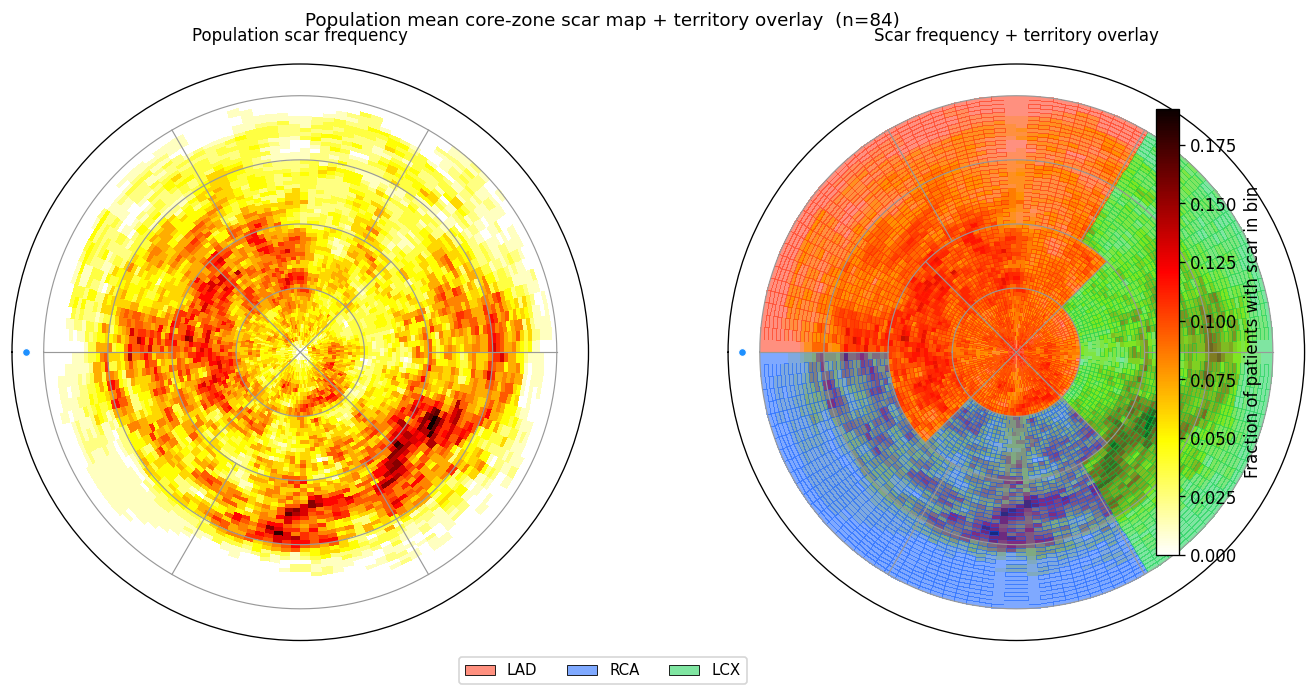

Saved population_scar_territory.png


In [9]:
if pmaps:
    pop_mean = np.stack(list(pmaps.values())).mean(axis=0)
    vmax_pm  = max(float(np.nanmax(pop_mean)), 1e-9)

    # Vivid, clearly distinct territory overlay colors
    OVERLAY_COLORS = {'LAD': '#ff2200', 'RCA': '#0055ff', 'LCX': '#00cc44'}
    OVERLAY_ALPHA  = 0.50

    fig, axes_pm = plt.subplots(1, 2, figsize=(12, 5.5),
                                subplot_kw={'projection': 'polar'})
    fig.suptitle(f'Population mean core-zone scar map + territory overlay  (n={len(pmaps)})',
                 fontsize=11)

    T_m, R_m = np.meshgrid(
        np.linspace(0, 2 * np.pi, N_THETA + 1),
        np.linspace(0, 1.0,       N_R + 1),
    )

    for ax_pm in axes_pm:
        mesh = ax_pm.pcolormesh(T_m, R_m, pop_mean, cmap='hot_r',
                                vmin=0, vmax=vmax_pm, shading='flat')
        t_full = np.linspace(0, 2 * np.pi, 361)
        for r_b in (0.25, 0.50, 0.75, 1.0):
            ax_pm.plot(t_full, np.full_like(t_full, r_b), color='#999', lw=0.7)
        for deg in (0, 60, 120, 180, 240, 300):
            ax_pm.plot([np.deg2rad(deg)] * 2, [0.5, 1.0], color='#999', lw=0.7)
        for deg in (45, 135, 225, 315):
            ax_pm.plot([np.deg2rad(deg)] * 2, [0.0, 0.5], color='#999', lw=0.7)
        ax_pm.set_theta_zero_location('W')
        ax_pm.set_theta_direction(-1)
        ax_pm.set_rticks([])
        ax_pm.set_xticks([])
        ax_pm.scatter([0.0], [1.07], s=22, color='dodgerblue',
                      edgecolor='white', linewidth=0.7, zorder=10, clip_on=False)
        for label, deg in [('ANT', 90), ('SEP', 0), ('INF', 270), ('LAT', 180)]:
            ax_pm.annotate(label, xy=(np.deg2rad(deg), 1.14), ha='center',
                           fontsize=8, color='#444', xycoords='data')

    axes_pm[0].set_title('Population scar frequency', fontsize=10, pad=14)

    # Territory overlay: distinct vivid colors at 50% alpha
    for terr, color in OVERLAY_COLORS.items():
        val_grid = (TERRITORY_GRID == terr).astype(float)
        cmap_t = mcolors.LinearSegmentedColormap.from_list(
            terr,
            [(1, 1, 1, 0.0),
             (*mcolors.to_rgb(color), OVERLAY_ALPHA)],
        )
        axes_pm[1].pcolormesh(T_m, R_m, val_grid, cmap=cmap_t,
                              vmin=0, vmax=1, shading='flat')
    axes_pm[1].set_title('Scar frequency + territory overlay', fontsize=10, pad=14)

    plt.colorbar(mesh, ax=axes_pm, orientation='vertical', fraction=0.02, pad=0.08,
                 label='Fraction of patients with scar in bin')

    legend_patches = [
        mpatches.Patch(facecolor=mcolors.to_rgba(OVERLAY_COLORS[t], alpha=OVERLAY_ALPHA),
                       edgecolor='black', linewidth=0.5, label=t)
        for t in TERRITORY
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=3,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    plt.tight_layout()
    plt.savefig(OUT / 'population_scar_territory.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved population_scar_territory.png')

## Section 6 - Age Correlations

### What is ANOVA?

**One-way ANOVA** tests whether the means of three or more groups differ
significantly. It decomposes total variance into *between-group* variance
(signal) and *within-group* variance (noise), producing an F-statistic.
A large F (small p) means at least one group mean differs from the others.

**Key assumptions**: normality within groups, equal variances (checked here
with Levene's test), and independent observations.

For the *within-patient* comparison across territories (LAD/RCA/LCX
are three measurements on the same patient), a **Friedman test** is used
instead because observations are not independent across territory groups.
Friedman is the non-parametric equivalent of repeated-measures ANOVA.

For *between-group* comparisons (e.g. sex), one-way ANOVA with Levene
variance check is appropriate since patients are independent.

### 6.1 Spearman + Pearson Correlations: Age vs Territory Scar Burden

Patients with age data: 32


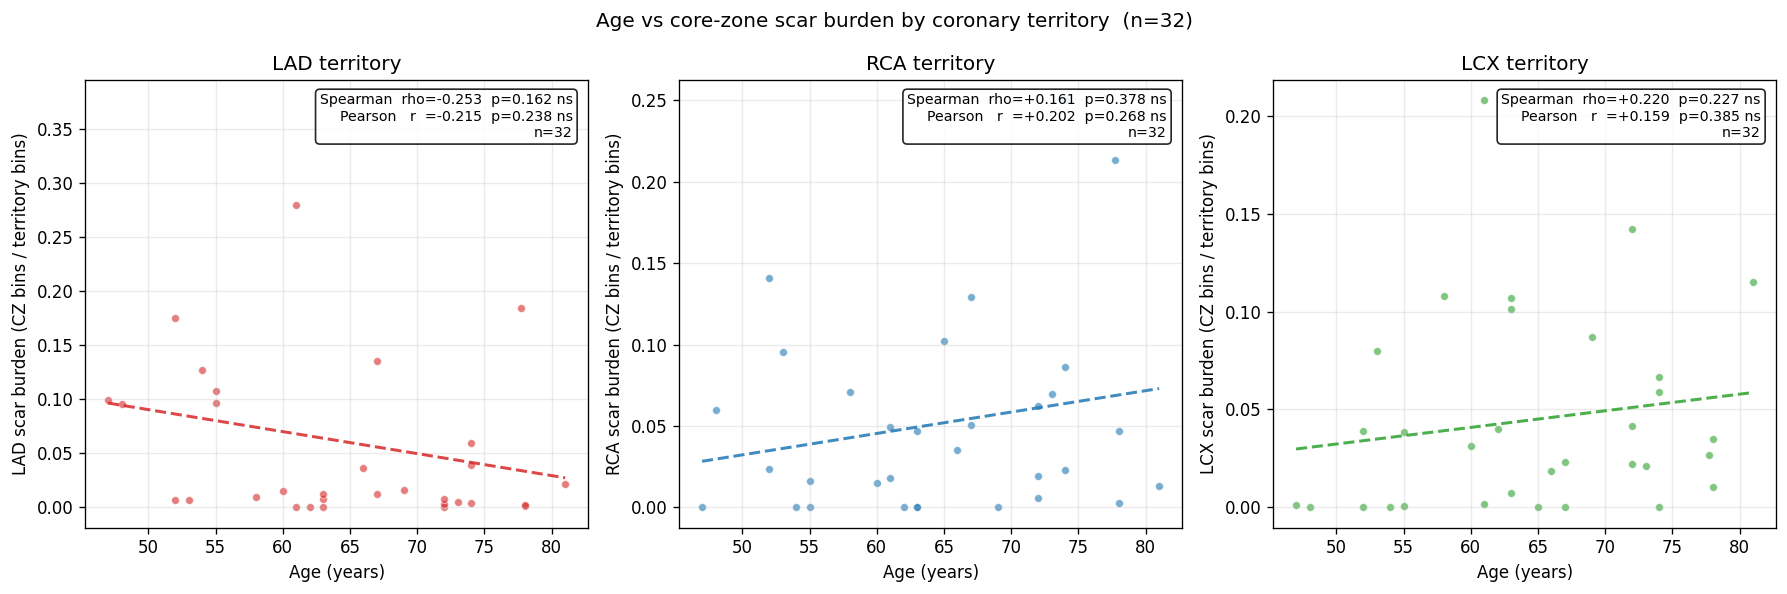

Saved age_territory_correlation.png


In [10]:
df_age = df.dropna(subset=['age'])
print(f'Patients with age data: {len(df_age)}')

fig, axes_age = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Age vs core-zone scar burden by coronary territory  (n={len(df_age)})',
    fontsize=12,
)

for ax, terr in zip(axes_age, ('LAD', 'RCA', 'LCX')):
    sub = df_age[['age', terr]].dropna()
    rho_s, p_s  = spearmanr(sub['age'], sub[terr])
    rho_p, p_p  = pearsonr(sub['age'], sub[terr])
    color = TERR_COLORS[terr]

    ax.scatter(sub['age'], sub[terr], alpha=0.6, s=22, color=color,
               edgecolors='white', linewidth=0.5)

    m, b = np.polyfit(sub['age'], sub[terr], 1)
    x_l  = np.linspace(sub['age'].min(), sub['age'].max(), 100)
    ax.plot(x_l, m * x_l + b, color=color, lw=1.8, alpha=0.85, ls='--')

    ax.set_xlabel('Age (years)')
    ax.set_ylabel(f'{terr} scar burden (CZ bins / territory bins)')
    ax.set_title(f'{terr} territory')
    sig_s = '**' if p_s < 0.01 else ('*' if p_s < 0.05 else 'ns')
    sig_p = '**' if p_p < 0.01 else ('*' if p_p < 0.05 else 'ns')
    ax.text(0.97, 0.97,
            f'Spearman  rho={rho_s:+.3f}  p={p_s:.3f} {sig_s}\n'
            f'Pearson   r  ={rho_p:+.3f}  p={p_p:.3f} {sig_p}\n'
            f'n={len(sub)}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(OUT / 'age_territory_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved age_territory_correlation.png')

### 6.2 Age vs Total Scar and Multi-Territory Involvement

C:\Users\joan\AppData\Local\Temp\ipykernel_34628\2622310139.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_ninv.boxplot(data_grp,


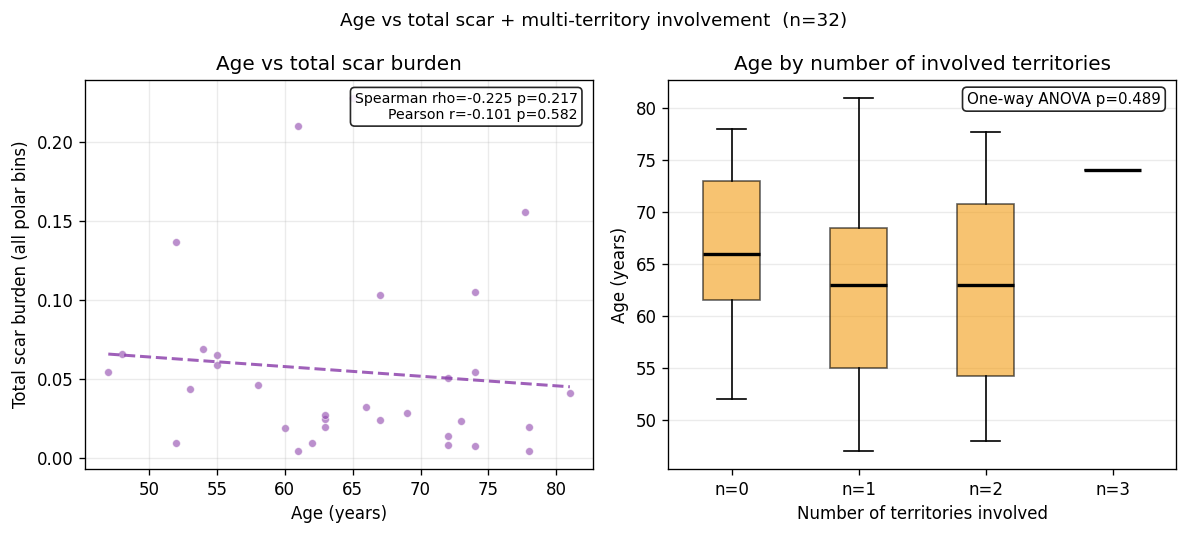

Saved age_total_scar.png


In [11]:
fig, (ax_tot, ax_ninv) = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle(f'Age vs total scar + multi-territory involvement  (n={len(df_age)})',
             fontsize=11)

sub_tot = df_age[['age', 'total_scar']].dropna()
rho_t, p_t = spearmanr(sub_tot['age'], sub_tot['total_scar'])
rho_tp, p_tp = pearsonr(sub_tot['age'], sub_tot['total_scar'])
ax_tot.scatter(sub_tot['age'], sub_tot['total_scar'], alpha=0.6, s=22,
               color='#8e44ad', edgecolors='white', linewidth=0.5)
m, b = np.polyfit(sub_tot['age'], sub_tot['total_scar'], 1)
x_l  = np.linspace(sub_tot['age'].min(), sub_tot['age'].max(), 100)
ax_tot.plot(x_l, m * x_l + b, color='#8e44ad', lw=1.8, ls='--', alpha=0.85)
ax_tot.set_xlabel('Age (years)')
ax_tot.set_ylabel('Total scar burden (all polar bins)')
ax_tot.set_title('Age vs total scar burden')
ax_tot.text(0.97, 0.97,
            f'Spearman rho={rho_t:+.3f} p={p_t:.3f}\nPearson r={rho_tp:+.3f} p={p_tp:.3f}',
            transform=ax_tot.transAxes, ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax_tot.grid(alpha=0.25)

sub_ninv = df_age[['age', 'n_involved']].dropna()
groups   = sorted(sub_ninv['n_involved'].unique())
data_grp = [sub_ninv.loc[sub_ninv['n_involved'] == g, 'age'].values for g in groups]
bp = ax_ninv.boxplot(data_grp,
                     labels=[f'n={int(g)}' for g in groups],
                     patch_artist=True, medianprops=dict(color='black', lw=2),
                     boxprops=dict(facecolor='#f39c12', alpha=0.6))
if len(data_grp) >= 2:
    _, p_kw2 = f_oneway(*data_grp)
    ax_ninv.text(0.97, 0.97, f'One-way ANOVA p={p_kw2:.3f}',
                 transform=ax_ninv.transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax_ninv.set_xlabel('Number of territories involved')
ax_ninv.set_ylabel('Age (years)')
ax_ninv.set_title('Age by number of involved territories')
ax_ninv.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(OUT / 'age_total_scar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved age_total_scar.png')

### 6.3 Age Correlations - Core Zone Only (Clinical Scalars)

The polar-map territory analysis above uses the core zone mesh (already isolated from
the border zone). As a complementary view, this section correlates age with the
**scalar clinical scar metrics** from the registry:

- `core_pct` — core zone as % of LV mass (ADAS3D output)
- `bz_core_pct` — core + border zone combined as % of LV mass
- `core_g` — core zone mass in grams

These provide a global (non-territory-specific) scar size estimate.

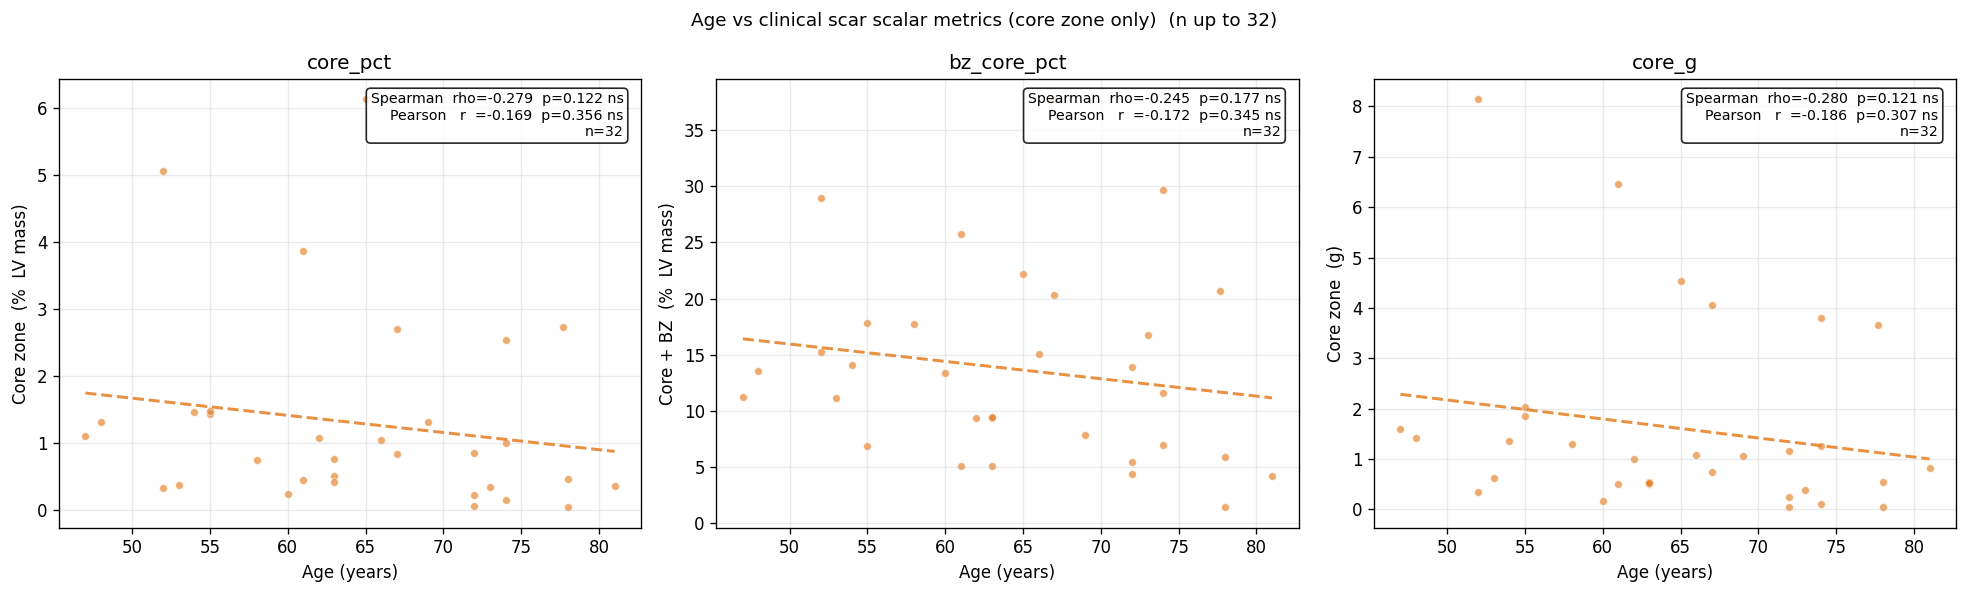

Saved age_core_zone_clinical.png


In [12]:
_scar_cols  = ['core_pct', 'bz_core_pct', 'core_g']
_scar_ylbls = [
    'Core zone  (%  LV mass)',
    'Core + BZ  (%  LV mass)',
    'Core zone  (g)',
]
_scar_cols_avail = [c for c in _scar_cols if df['age'].notna().any() and df[c].notna().any()]

if not _scar_cols_avail:
    print('No clinical scar scalar data available.')
else:
    fig, axes_cz = plt.subplots(1, len(_scar_cols_avail),
                                figsize=(5.5 * len(_scar_cols_avail), 5))
    if len(_scar_cols_avail) == 1:
        axes_cz = [axes_cz]
    fig.suptitle(
        f'Age vs clinical scar scalar metrics (core zone only)  (n up to {len(df_age)})',
        fontsize=11,
    )

    for ax, col, ylabel in zip(axes_cz, _scar_cols_avail,
                                [_scar_ylbls[_scar_cols.index(c)] for c in _scar_cols_avail]):
        sub_cz = df_age[['age', col]].dropna()
        if len(sub_cz) < 5:
            ax.set_title(f'{col}\n(insufficient data n={len(sub_cz)})')
            ax.axis('off')
            continue

        rho_s, p_s = spearmanr(sub_cz['age'], sub_cz[col])
        rho_p, p_p = pearsonr(sub_cz['age'], sub_cz[col])

        ax.scatter(sub_cz['age'], sub_cz[col], alpha=0.65, s=22,
                   color='#e67e22', edgecolors='white', linewidth=0.5)
        m, b = np.polyfit(sub_cz['age'], sub_cz[col], 1)
        x_l  = np.linspace(sub_cz['age'].min(), sub_cz['age'].max(), 100)
        ax.plot(x_l, m * x_l + b, color='#e67e22', lw=1.8, ls='--', alpha=0.85)

        ax.set_xlabel('Age (years)')
        ax.set_ylabel(ylabel)
        ax.set_title(col)
        sig_s = '**' if p_s < 0.01 else ('*' if p_s < 0.05 else 'ns')
        sig_p = '**' if p_p < 0.01 else ('*' if p_p < 0.05 else 'ns')
        ax.text(0.97, 0.97,
                f'Spearman  rho={rho_s:+.3f}  p={p_s:.3f} {sig_s}\n'
                f'Pearson   r  ={rho_p:+.3f}  p={p_p:.3f} {sig_p}\n'
                f'n={len(sub_cz)}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(OUT / 'age_core_zone_clinical.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved age_core_zone_clinical.png')

## Section 7 - Sex Differences in Coronary Territory Scar

**Two-sample t-test** (Welch, unequal variances): tests whether the mean scar
burden differs between male and female patients in each territory.
Assumptions: independent groups, approximately normal distributions.
Levene's test is reported to verify the equal-variance assumption.

**One-way ANOVA across territories within each sex group**: tests whether
mean scar burden differs across the three territories (LAD/RCA/LCX)
separately for males and females. This shows whether the territory
distribution pattern itself differs by sex.

> **Note**: post-MI cohorts skew heavily male; interpret female results
> cautiously given typically smaller sample size.

### 7.1 T-test: Male vs Female by Territory

Males: 27   Females: 5


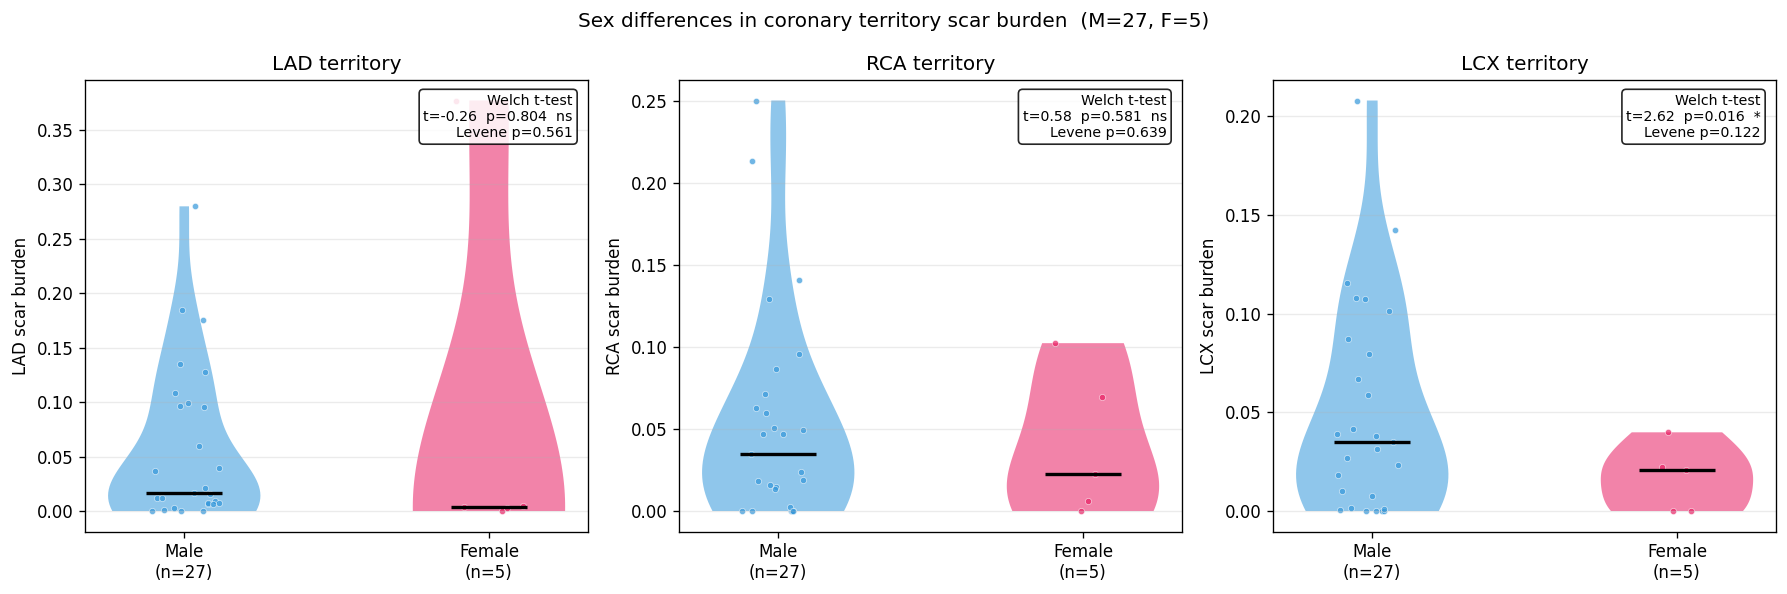

Saved sex_territory_ttest.png

Welch t-test summary (male vs female, two-sided):
  LAD: M mean=0.0576  F mean=0.0777  p=0.8040  ns
  RCA: M mean=0.0535  F mean=0.0400  p=0.5811  ns
  LCX: M mean=0.0499  F mean=0.0166  p=0.0158  *


In [13]:
df_sex  = df.dropna(subset=['sex'])
males   = df_sex[df_sex['sex'] == 'M']
females = df_sex[df_sex['sex'] == 'F']
print(f'Males: {len(males)}   Females: {len(females)}')

fig, axes_sex = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Sex differences in coronary territory scar burden  '
    f'(M={len(males)}, F={len(females)})',
    fontsize=12,
)

rng = np.random.default_rng(42)

for ax, terr in zip(axes_sex, ('LAD', 'RCA', 'LCX')):
    m_vals = males[terr].dropna().values
    f_vals = females[terr].dropna().values

    # Welch two-sample t-test (does not assume equal variances)
    if len(m_vals) >= 2 and len(f_vals) >= 2:
        t_stat, p_tt = ttest_ind(m_vals, f_vals, equal_var=False)
        lev_stat, p_lev = levene(m_vals, f_vals)
    else:
        t_stat, p_tt, lev_stat, p_lev = np.nan, np.nan, np.nan, np.nan

    vp = ax.violinplot([m_vals, f_vals], positions=[1, 2],
                       showmedians=True, showextrema=False)
    for pc, color in zip(vp['bodies'], ['#3498db', '#e91e63']):
        pc.set_facecolor(color)
        pc.set_alpha(0.55)
    vp['cmedians'].set_color('black')
    vp['cmedians'].set_linewidth(2)

    for vals, pos, color in [(m_vals, 1, '#3498db'), (f_vals, 2, '#e91e63')]:
        jitter = rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(np.full(len(vals), pos) + jitter, vals,
                   s=14, alpha=0.7, color=color, edgecolors='white', linewidth=0.4)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'Male\n(n={len(m_vals)})', f'Female\n(n={len(f_vals)})'])
    ax.set_ylabel(f'{terr} scar burden')
    ax.set_title(f'{terr} territory')

    sig = '**' if p_tt < 0.01 else ('*' if p_tt < 0.05 else 'ns')
    lev_txt = f'Levene p={p_lev:.3f}' if not np.isnan(p_lev) else ''
    ax.text(0.97, 0.97,
            f'Welch t-test\nt={t_stat:.2f}  p={p_tt:.3f}  {sig}\n{lev_txt}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(OUT / 'sex_territory_ttest.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved sex_territory_ttest.png')

print('\nWelch t-test summary (male vs female, two-sided):')
for terr in ('LAD', 'RCA', 'LCX'):
    m_v = males[terr].dropna().values
    f_v = females[terr].dropna().values
    if len(m_v) >= 2 and len(f_v) >= 2:
        _, p = ttest_ind(m_v, f_v, equal_var=False)
        sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'ns')
        print(f'  {terr}: M mean={m_v.mean():.4f}  F mean={f_v.mean():.4f}  '
              f'p={p:.4f}  {sig}')

### 7.2 One-Way ANOVA: Territory Differences Within Each Sex

=== One-way ANOVA: territory differences within each sex ===
(Caveat: LAD/RCA/LCX are within-patient; Friedman test also shown)

All patients (n=32):
  One-way ANOVA  F=0.43  p=0.6506  ns
  Friedman chi2=0.43  p=0.806
  Means: LAD=0.0608  RCA=0.0514  LCX=0.0447

Males (n=27):
  One-way ANOVA  F=0.10  p=0.9073  ns
  Friedman chi2=0.17  p=0.919
  Means: LAD=0.0576  RCA=0.0535  LCX=0.0499

Females (n=5):
  One-way ANOVA  F=0.47  p=0.6348  ns
  Friedman chi2=0.95  p=0.623
  Means: LAD=0.0777  RCA=0.0400  LCX=0.0166



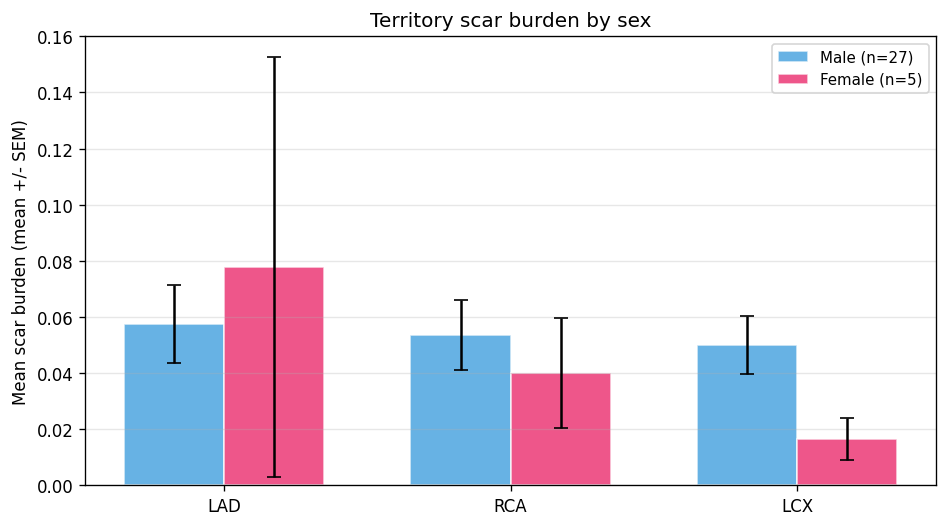

Saved territory_burden_by_sex.png


In [14]:
# One-way ANOVA: does scar burden differ across LAD/RCA/LCX within each sex?
# Note: observations are not fully independent (same patient measured 3 times),
# so Friedman test is also computed as a check.

print('=== One-way ANOVA: territory differences within each sex ===')
print('(Caveat: LAD/RCA/LCX are within-patient; Friedman test also shown)\n')

for grp_label, grp_df in [('All patients', df_sex),
                            ('Males', males),
                            ('Females', females)]:
    lad = grp_df['LAD'].dropna().values
    rca = grp_df['RCA'].dropna().values
    lcx = grp_df['LCX'].dropna().values
    if min(len(lad), len(rca), len(lcx)) < 3:
        print(f'{grp_label}: insufficient data')
        continue

    f_stat, p_anova = f_oneway(lad, rca, lcx)
    # Align arrays to same length for Friedman (within-patient pairs)
    sub = grp_df[['LAD', 'RCA', 'LCX']].dropna()
    if len(sub) >= 3:
        fr_stat, p_fr = friedmanchisquare(sub['LAD'].values,
                                          sub['RCA'].values,
                                          sub['LCX'].values)
        fr_str = f'  Friedman chi2={fr_stat:.2f}  p={p_fr:.3f}'
    else:
        fr_str = '  Friedman: n too small'

    sig = '**' if p_anova < 0.01 else ('*' if p_anova < 0.05 else 'ns')
    print(f'{grp_label} (n={len(grp_df)}):')
    print(f'  One-way ANOVA  F={f_stat:.2f}  p={p_anova:.4f}  {sig}')
    print(fr_str)
    print(f'  Means: LAD={lad.mean():.4f}  RCA={rca.mean():.4f}  LCX={lcx.mean():.4f}\n')

# Summary bar: mean territory burden stratified by sex
fig2, ax2 = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(3)
width = 0.35
for offset, (grp_lbl, grp_df, color) in enumerate(
    [('Male', males, '#3498db'), ('Female', females, '#e91e63')]
):
    means = [grp_df[t].mean() for t in ('LAD', 'RCA', 'LCX')]
    sems  = [grp_df[t].sem()  for t in ('LAD', 'RCA', 'LCX')]
    bars  = ax2.bar(x_pos + offset * width, means, width,
                    yerr=sems, capsize=4,
                    label=f'{grp_lbl} (n={len(grp_df)})',
                    color=color, alpha=0.75, edgecolor='white')
ax2.set_xticks(x_pos + width / 2)
ax2.set_xticklabels(['LAD', 'RCA', 'LCX'])
ax2.set_ylabel('Mean scar burden (mean +/- SEM)')
ax2.set_title('Territory scar burden by sex')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'territory_burden_by_sex.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved territory_burden_by_sex.png')

### 7.3 Dominant Territory by Sex

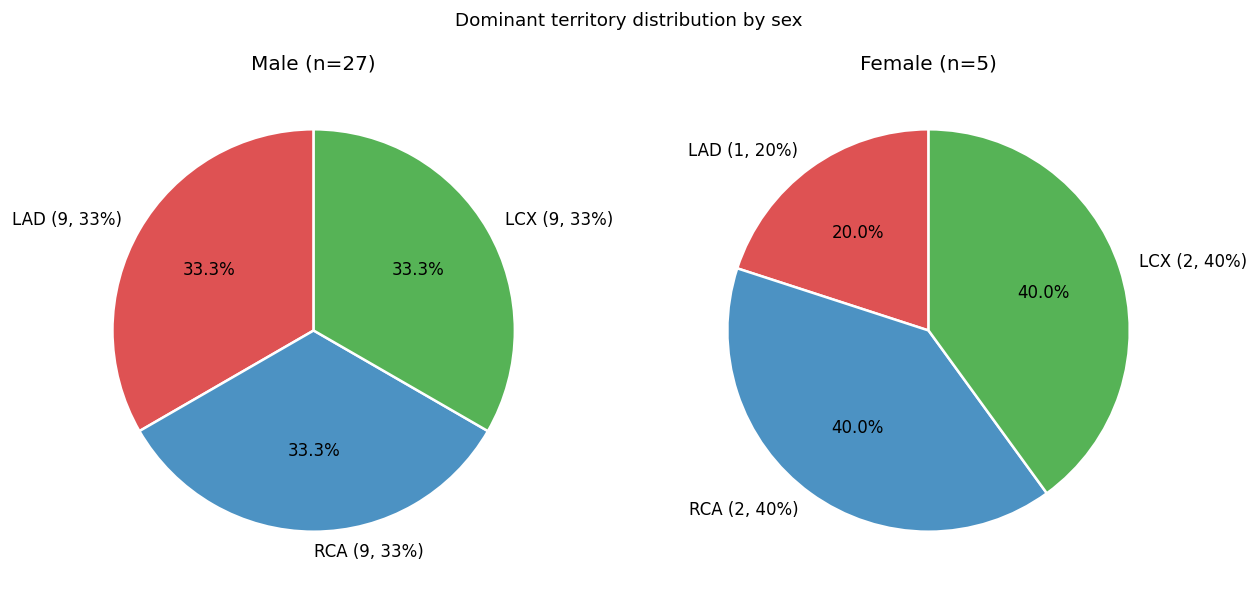

Saved dominant_territory_by_sex.png


In [15]:
if len(df_sex) > 0:
    fig, axes_dom = plt.subplots(1, 2, figsize=(11, 5))
    fig.suptitle('Dominant territory distribution by sex', fontsize=11)

    for ax, (grp_lbl, gdf) in zip(axes_dom, [('Male', males), ('Female', females)]):
        if len(gdf) == 0:
            ax.set_title(f'{grp_lbl} (n=0)')
            ax.axis('off')
            continue
        dom_g       = gdf['dominant'].value_counts()
        dom_order_g = [t for t in ('LAD', 'RCA', 'LCX') if t in dom_g.index]
        dom_vals_g  = [dom_g.get(t, 0) for t in dom_order_g]
        dom_cols_g  = [mcolors.to_rgba(TERR_COLORS[t], alpha=0.80) for t in dom_order_g]
        ax.pie(
            dom_vals_g,
            labels=[f'{t} ({v}, {100*v/len(gdf):.0f}%)'
                    for t, v in zip(dom_order_g, dom_vals_g)],
            colors=dom_cols_g,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5),
        )
        ax.set_title(f'{grp_lbl} (n={len(gdf)})')

    plt.tight_layout()
    plt.savefig(OUT / 'dominant_territory_by_sex.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved dominant_territory_by_sex.png')

## Summary

| Output file | Contents |
|---|---|
| `example_polar_maps.png` | Binary core-zone polar maps for the first 12 cases |
| `territory_population.png` | Mean burden per territory (numerator/denominator annotated), dominant territory pie, multi-territory bar |
| `population_scar_territory.png` | Population mean polar map + vivid territory color overlay |
| `age_territory_correlation.png` | Spearman + Pearson r(age, LAD/RCA/LCX burden) scatter plots |
| `age_total_scar.png` | Age vs total scar + ANOVA by n_territories |
| `age_core_zone_clinical.png` | Age vs clinical core_pct / bz_core_pct / core_g |
| `sex_territory_ttest.png` | Welch t-test + Levene test violin plots by sex |
| `territory_burden_by_sex.png` | Grouped bar: territory burden by sex + one-way ANOVA |
| `dominant_territory_by_sex.png` | Dominant territory pie by sex |

**Statistical tests used:**
- Friedman test (non-parametric repeated measures) for within-patient territory comparison.
- Spearman rho + Pearson r for age correlations.
- Welch t-test (unequal variances) for male vs female comparisons.
- One-way ANOVA for territory differences within sex groups.
- Bonferroni correction for 3 territory comparisons: alpha = 0.017.

**Limitations:**
- AHA territory assignment is a standard approximation; no angiographic data available.
- Segment 17 (apical cap) assigned to LAD; actual supply is variable.
- One-way ANOVA across territories is approximate because LAD/RCA/LCX are within-patient measures.